In [1]:
# ============================================================
# KONFIGURASI — sesuaikan bagian ini
# ============================================================

# Path folder frames input (dari Kaggle Dataset)
INPUT_DIR    = "/kaggle/input/datasets/akmalfayyazi/framess/low-light-image.png"

# Model yang dipakai: 'SDSD_outdoor' atau 'LOL_v1'
MODEL_NAME   = "SDSD_outdoor"

# Resize sisi terpanjang (0 = tidak resize); turunkan jika OOM
MAX_SIDE     = 2560

# FPS video output — sesuaikan dengan FPS video asli
FPS          = 30

# ============================================================
# Path otomatis (tidak perlu diubah)
# ============================================================

import os

MODEL_CONFIG = f"Options/RetinexFormer_{MODEL_NAME}.yml"
MODEL_WEIGHT = f"pretrained_weights/{MODEL_NAME}.pth"

ENHANCED_DIR = f"/kaggle/working/enhanced_frames_{MODEL_NAME}"
OUTPUT_VIDEO = f"/kaggle/working/output-retinex-{MODEL_NAME}.mp4"
RESULTS_DIR  = "/kaggle/working/results"

for d in [ENHANCED_DIR, RESULTS_DIR, os.path.dirname(OUTPUT_VIDEO)]:
    os.makedirs(d, exist_ok=True)

print("✅ Konfigurasi berhasil dimuat")
print(f"   Input dir    : {INPUT_DIR}")
print(f"   Model        : {MODEL_NAME}")
print(f"   Config       : {MODEL_CONFIG}")
print(f"   Weights      : {MODEL_WEIGHT}")
print(f"   Enhanced dir : {ENHANCED_DIR}")
print(f"   Output video : {OUTPUT_VIDEO}")

✅ Konfigurasi berhasil dimuat
   Input dir    : /kaggle/input/datasets/akmalfayyazi/framess/low-light-image.png
   Model        : SDSD_outdoor
   Config       : Options/RetinexFormer_SDSD_outdoor.yml
   Weights      : pretrained_weights/SDSD_outdoor.pth
   Enhanced dir : /kaggle/working/enhanced_frames_SDSD_outdoor
   Output video : /kaggle/working/output-retinex-SDSD_outdoor.mp4


---
## Step 1 — Install Dependencies & Clone Retinexformer

In [2]:
!git clone https://github.com/caiyuanhao1998/Retinexformer
%cd Retinexformer
!pip install -q matplotlib scikit-learn scikit-image opencv-python yacs joblib natsort \
    h5py tqdm tensorboard einops gdown addict future lmdb numpy pyyaml requests \
    scipy yapf lpips thop timm
!python setup.py develop --no_cuda_ext

Cloning into 'Retinexformer'...
remote: Enumerating objects: 712, done.
remote: Counting objects: 100% (269/269), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 712 (delta 243), reused 187 (delta 187), pack-reused 443 (from 2)
Receiving objects: 100% (712/712), 16.30 MiB | 25.13 MiB/s, done.
Resolving deltas: 100% (383/383), done.
/kaggle/working/Retinexformer
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.6 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-

---
## Step 2 — Download Pretrained Weights

In [3]:
!gdown --folder https://drive.google.com/drive/folders/1ynK5hfQachzc8y96ZumhkPPDXzHJwaQV -O pretrained_weights_all
!mkdir -p pretrained_weights
!find pretrained_weights_all -iname "{MODEL_NAME}.pth" -exec cp {{}} pretrained_weights/ \;
!ls pretrained_weights

Retrieving folder contents
Retrieving folder 15bEHNveVvYKGrXmqDpBiaBxXTyxinsl5 MST_Plus_Plus_NTIRE
Processing file 11uTfmk6GCseVAyTFwLzaztmUP4rKrOQC MST_Plus_Plus_4x1800.pth
Processing file 1EUX513nFaoG_LLxkxuDZMl0EWRxW-R3A MST_Plus_Plus_8x1150.pth
Processing file 1oxvPPfhbOwZURTFenWnFp3H3Lakkqw3t FiveK.pth
Processing file 1xDwQtTCj3tlAVCTJgYrzonBGVwqeOhKu LOL_v1.pth
Processing file 1tChRwTfqhs-A67QzG8a9Lrx7qKB3m89K LOL_v2_real.pth
Processing file 1VPNTcVhzwSQ1PcSyYOuZIgrclITM6F_b LOL_v2_synthetic.pth
Processing file 1K-QR-A_CPe6iAgjE6_04Q20DkkVwaVta NTIRE.pth
Processing file 1k-9LhI30k5Gp-L1K2RgV_eAXP8tnxgaF SDSD_indoor.pth
Processing file 1rcyDa39uauCfOBs4GF8ZGmLWPFFqaw9i SDSD_outdoor.pth
Processing file 1wiPppvWVNFxm6I9sJJiiERBttGjlWsGo SID.pth
Processing file 1bpl02zj1ID-aZHd7paTWVEFWfbB8iktl SMID.pth
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=11uTfmk6GCseVAyTFwLzaztmUP

In [4]:
%%writefile batch_infer.py

import os
import sys
import argparse
import torch
import numpy as np
from tqdm import tqdm
from PIL import Image
import cv2

# ──────────────────────────────────────────────────────────────────────────────
# Argument Parser
# ──────────────────────────────────────────────────────────────────────────────

def parse_args():
    parser = argparse.ArgumentParser(description="RetinexFormer Batch Inference")
    parser.add_argument("--input_dir",  type=str, required=True,
                        help="Path ke folder frames / file gambar tunggal")
    parser.add_argument("--output_dir", type=str, required=True,
                        help="Folder output enhanced frames")
    parser.add_argument("--opt",        type=str, required=True,
                        help="Path ke file .yml konfigurasi model")
    parser.add_argument("--weights",    type=str, required=True,
                        help="Path ke file .pth pretrained weights")
    parser.add_argument("--max_side",   type=int, default=0,
                        help="Resize sisi terpanjang (0 = tidak resize)")
    return parser.parse_args()


# ──────────────────────────────────────────────────────────────────────────────
# Utility: kumpulkan list file gambar dari input_dir (atau file tunggal)
# ──────────────────────────────────────────────────────────────────────────────

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def collect_images(input_path: str):
    if os.path.isfile(input_path):
        return [input_path]
    files = sorted([
        os.path.join(input_path, f)
        for f in os.listdir(input_path)
        if os.path.splitext(f)[1].lower() in IMG_EXTS
    ])
    return files


# ──────────────────────────────────────────────────────────────────────────────
# Utility: resize jika max_side > 0
# ──────────────────────────────────────────────────────────────────────────────

def maybe_resize(img_np: np.ndarray, max_side: int):
    """img_np: HxWxC uint8. Returns resized array (dan scale factor)."""
    if max_side <= 0:
        return img_np, 1.0
    h, w = img_np.shape[:2]
    longest = max(h, w)
    if longest <= max_side:
        return img_np, 1.0
    scale = max_side / longest
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    resized = cv2.resize(img_np, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized, scale


# ──────────────────────────────────────────────────────────────────────────────
# Load model dari konfigurasi RetinexFormer
# ──────────────────────────────────────────────────────────────────────────────

def load_model(opt_path: str, weight_path: str, device: torch.device):
    from basicsr.utils.options import parse
    from basicsr.models import create_model

    # parse YAML → dict
    opt = parse(opt_path, is_train=False)
    opt["dist"] = False
    opt["is_train"] = False

    # override path pretrained
    opt.setdefault("path", {})
    opt["path"]["pretrain_network_g"] = weight_path
    opt["path"]["strict_load_g"] = True

    model = create_model(opt)
    return model


# ──────────────────────────────────────────────────────────────────────────────
# Inference satu gambar
# ──────────────────────────────────────────────────────────────────────────────

def infer_image(model, img_np: np.ndarray, device: torch.device) -> np.ndarray:
    """
    img_np : HxWxC uint8 BGR (OpenCV format)
    returns: HxWxC uint8 BGR enhanced
    """
    # BGR → RGB, normalize ke [0,1]
    img_rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # HxWxC → 1xCxHxW tensor
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        # RetinexFormer / basicsr interface
        model.feed_data({"lq": tensor})
        model.test()
        out = model.get_current_visuals()["result"]  # 1xCxHxW, [0,1]

    # tensor → numpy BGR uint8
    out_np = out.squeeze(0).permute(1, 2, 0).cpu().numpy()
    out_np = np.clip(out_np * 255.0, 0, 255).astype(np.uint8)
    out_bgr = cv2.cvtColor(out_np, cv2.COLOR_RGB2BGR)
    return out_bgr


# ──────────────────────────────────────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────────────────────────────────────

def main():
    args = parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Load model
    model = load_model(args.opt, args.weights, device)

    # Kumpulkan frame
    image_files = collect_images(args.input_dir)
    n = len(image_files)
    if n == 0:
        print(f"❌ Tidak ada gambar ditemukan di: {args.input_dir}")
        sys.exit(1)
    print(f"Ditemukan {n} frame")

    os.makedirs(args.output_dir, exist_ok=True)

    for img_path in tqdm(image_files):
        img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"⚠️  Gagal membaca: {img_path}, dilewati.")
            continue

        # resize jika perlu
        img_resized, _ = maybe_resize(img_bgr, args.max_side)

        # inference
        enhanced = infer_image(model, img_resized, device)

        # simpan dengan nama yang sama
        fname = os.path.basename(img_path)
        out_path = os.path.join(args.output_dir, fname)
        cv2.imwrite(out_path, enhanced)

    print(f"\n✅ Selesai. Frame tersimpan di: {args.output_dir}")


if __name__ == "__main__":
    main()

Writing batch_infer.py


---
## Step 4 — Jalankan Inference

In [5]:
!cp pretrained_weights_all/SDSD_outdoor.pth pretrained_weights/SDSD_outdoor.pth

In [8]:
import re

path = "batch_infer.py"
with open(path, "r") as f:
    code = f.read()

old = """    with torch.no_grad():
        # RetinexFormer / basicsr interface
        model.feed_data({"lq": tensor})
        model.test()
        out = model.get_current_visuals()["result"]  # 1xCxHxW, [0,1]"""

new = """    with torch.no_grad():
        out = model.net_g(tensor)"""

code = code.replace(old, new)
with open(path, "w") as f:
    f.write(code)

print("✅ batch_infer.py berhasil di-patch")

✅ batch_infer.py berhasil di-patch


In [9]:
!python batch_infer.py \
    --input_dir  "{INPUT_DIR}" \
    --output_dir "{ENHANCED_DIR}" \
    --opt        "{MODEL_CONFIG}" \
    --weights    "{MODEL_WEIGHT}" \
    --max_side   {MAX_SIDE}

Device: cuda
/kaggle/working/Retinexformer/basicsr/models/image_restoration_model.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_scaler = GradScaler(enabled=self.use_amp)
Not using Automatic Mixed Precision
 load net keys <built-in method keys of collections.OrderedDict object at 0x7a5a4a410640>
Ditemukan 1 frame
100%|█████████████████████████████████████████████| 1/1 [00:04<00:00,  4.19s/it]

✅ Selesai. Frame tersimpan di: /kaggle/working/enhanced_frames_SDSD_outdoor


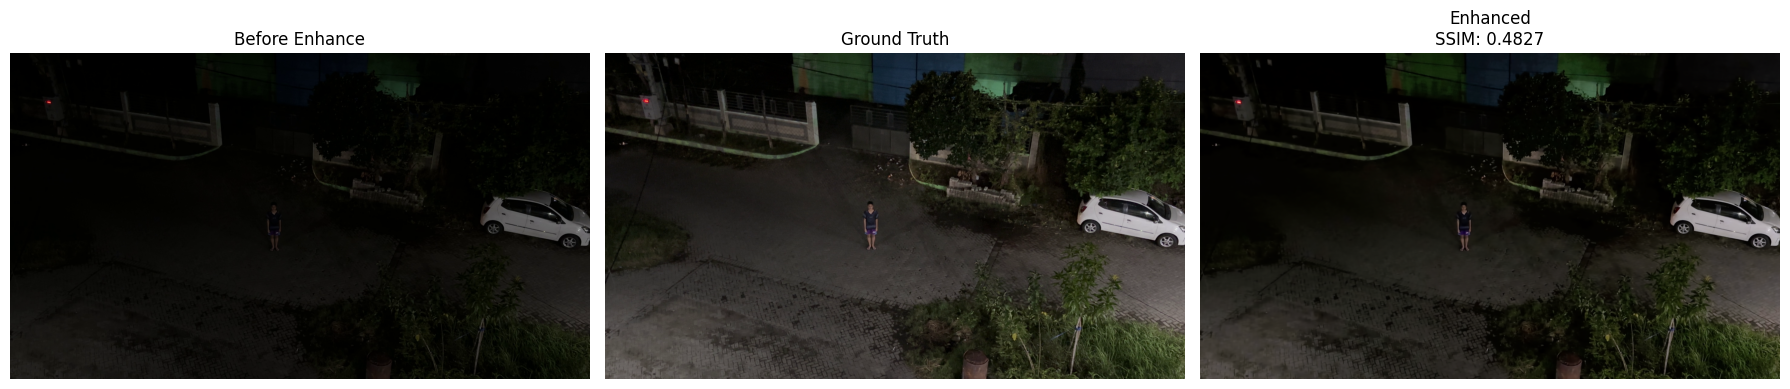

SSIM: 0.4827


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import os

# ── KONFIGURASI ──
GROUND_TRUTH_DIR = "/kaggle/input/datasets/akmalfayyazi/framess/target.png"
INPUT_DIR_VIZ    = INPUT_DIR
ENHANCED_DIR_VIZ = ENHANCED_DIR

# ── LOAD GAMBAR ──
if os.path.isfile(INPUT_DIR_VIZ):
    input_files = [INPUT_DIR_VIZ]
else:
    exts = {".png", ".jpg", ".jpeg"}
    input_files = sorted([
        os.path.join(INPUT_DIR_VIZ, f)
        for f in os.listdir(INPUT_DIR_VIZ)
        if os.path.splitext(f)[1].lower() in exts
    ])

idx = 0
fname = os.path.basename(input_files[idx])

img_input    = cv2.cvtColor(cv2.imread(input_files[idx]), cv2.COLOR_BGR2RGB)
img_enhanced = cv2.cvtColor(cv2.imread(os.path.join(ENHANCED_DIR_VIZ, fname)), cv2.COLOR_BGR2RGB)

if os.path.isfile(GROUND_TRUTH_DIR):
    img_gt = cv2.cvtColor(cv2.imread(GROUND_TRUTH_DIR), cv2.COLOR_BGR2RGB)
    gt_bgr = cv2.imread(GROUND_TRUTH_DIR)
else:
    img_gt = cv2.cvtColor(cv2.imread(os.path.join(GROUND_TRUTH_DIR, fname)), cv2.COLOR_BGR2RGB)
    gt_bgr = cv2.imread(GROUND_TRUTH_DIR) if os.path.isfile(GROUND_TRUTH_DIR) else cv2.imread(os.path.join(GROUND_TRUTH_DIR, fname))

# ── SSIM ──
img_enhanced_gray = cv2.cvtColor(img_enhanced, cv2.COLOR_RGB2GRAY)
img_gt_gray       = cv2.cvtColor(img_gt,       cv2.COLOR_RGB2GRAY)

if img_gt_gray.shape != img_enhanced_gray.shape:
    img_gt_gray = cv2.resize(img_gt_gray, (img_enhanced_gray.shape[1], img_enhanced_gray.shape[0]))

ssim_val, _ = ssim(img_gt_gray, img_enhanced_gray, full=True)

# ── PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_input);    axes[0].set_title("Before Enhance"); axes[0].axis("off")
axes[1].imshow(img_gt);       axes[1].set_title("Ground Truth");   axes[1].axis("off")
axes[2].imshow(img_enhanced); axes[2].set_title(f"Enhanced\nSSIM: {ssim_val:.4f}"); axes[2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"comparison_{fname}"), dpi=150, bbox_inches="tight")
plt.show()
print(f"SSIM: {ssim_val:.4f}")

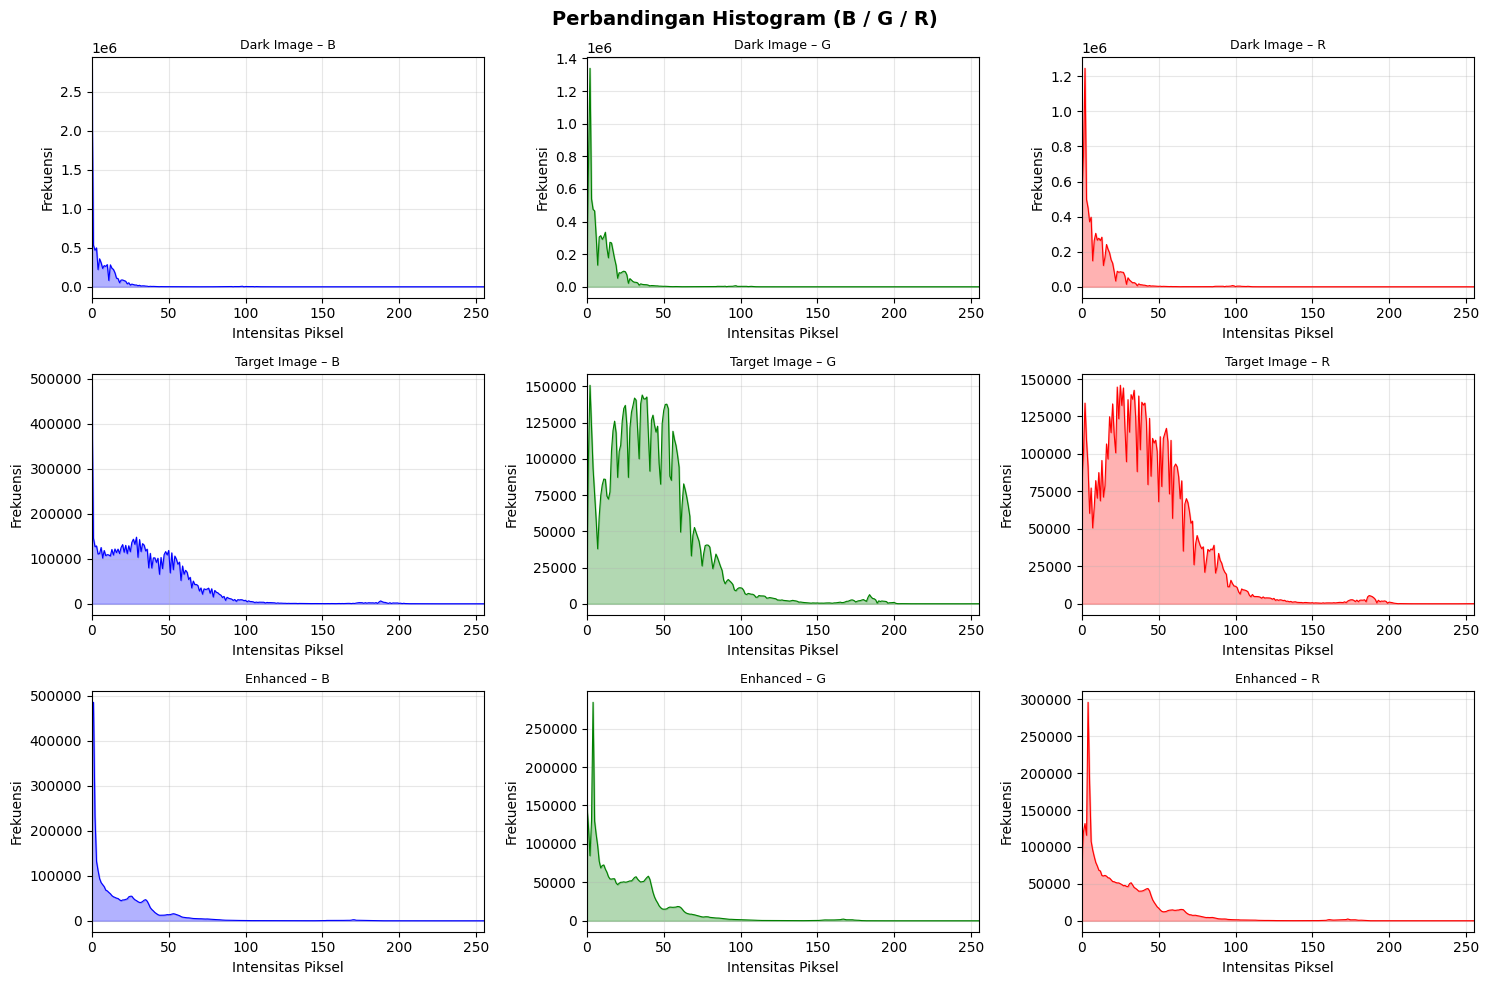

Histogram disimpan: /kaggle/working/results/histograms.png


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_histograms(dark_img, target_img, enhanced_img, save_path=None):
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    fig.suptitle("Perbandingan Histogram (B / G / R)", fontsize=14, fontweight="bold")

    titles = ["Dark Image", "Target Image", "Enhanced"]
    images = [dark_img, target_img, enhanced_img]
    colors = ["blue", "green", "red"]

    for row, (img, title) in enumerate(zip(images, titles)):
        for col, (ch_idx, color) in enumerate(zip([0, 1, 2], colors)):
            ax = axes[row][col]
            hist = cv2.calcHist([img], [ch_idx], None, [256], [0, 256])
            ax.plot(hist, color=color, linewidth=0.8)
            ax.fill_between(range(256), hist.ravel(), alpha=0.3, color=color)
            ax.set_xlim([0, 255])
            ax.set_title(f"{title} – {'BGR'[col]}", fontsize=9)
            ax.set_xlabel("Intensitas Piksel")
            ax.set_ylabel("Frekuensi")
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out = save_path or os.path.join(RESULTS_DIR, "histograms.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Histogram disimpan: {out}")

# ── Load gambar ──
fname = os.path.basename(input_files[idx])  # pakai idx dari cell SSIM sebelumnya

dark_bgr     = cv2.imread(input_files[idx])
gt_bgr = cv2.imread(GROUND_TRUTH_DIR) if os.path.isfile(GROUND_TRUTH_DIR) else cv2.imread(os.path.join(GROUND_TRUTH_DIR, fname))
enhanced_bgr = cv2.imread(os.path.join(ENHANCED_DIR_VIZ, fname))

plot_histograms(dark_bgr, gt_bgr, enhanced_bgr)